# CSE 4/587 — End-to-End Big Data Pipeline
# Project Phase 1 Report

**Project Title:** Stock Movement Prediction

**Dataset:** S&P 500 Stock Prices (2014–2017)

**Team Members:**
- Harshvardhan Shinde (hdshinde) — hdshinde@buffalo.edu
- Lorenzo Price (lorenzop) — lorenzop@buffalo.edu
- Qiang Wu (qiangwu2) — qiangwu2@buffalo.edu

**Date:** March 14, 2026

---

## Task 1: Problem Statement (20 pts)

### Project Title
**Stock Movement Prediction Using S&P 500 Historical Data**

### Problem Description & Motivation
The stock market is one of the most complex and dynamic financial systems, influenced by countless factors ranging from macroeconomic indicators to investor sentiment. Predicting stock movements has been a long-standing challenge in both finance and computer science. With the availability of large-scale historical trading data, machine learning provides a data-driven approach to uncovering patterns that traditional financial models may miss.

This project uses the **S&P 500 Stock Prices (2014–2017)** dataset, which contains daily OHLCV (Open, High, Low, Close, Volume) data for 505 stocks over 1,006 trading days. By augmenting this data with sector and company information, we aim to build predictive models that can assist investors, portfolio managers, and financial analysts in making more informed decisions.

### Stakeholders
- **Retail and Institutional Investors:** Benefit from data-driven signals to optimize buy/sell decisions.
- **Portfolio Managers:** Use sector-level insights and risk metrics for portfolio diversification and rebalancing.
- **Financial Analysts:** Leverage automated pattern detection to supplement fundamental analysis.
- **Risk Management Teams:** Identify high-volatility stocks and sector-level risk concentrations.

### Machine Learning Problem Statements (N=3)

**Problem 1: Classification — Predict Daily Stock Price Direction**
Given a stock's historical features (previous closing price, volume, daily return, price range, sector, and temporal features), predict whether the stock's closing price will go **up or down** on the next trading day. This is a binary classification problem. Success metric: accuracy, F1-score, and AUC-ROC. Algorithms to explore include Logistic Regression, Random Forest, and Gradient Boosting (XGBoost).

**Problem 2: Regression — Forecast Daily Percentage Return**
Given the same feature set, predict the **exact percentage change** in a stock's price for the next trading day. This is a continuous regression problem. Success metric: RMSE, MAE, and R². Algorithms to explore include Linear Regression, Ridge/Lasso Regression, and Support Vector Regression (SVR).

**Problem 3: Clustering — Group Stocks by Trading Behavior**
Using features such as average daily return, volatility (standard deviation of returns), average volume, and price range, **cluster stocks into groups** with similar trading profiles. This is an unsupervised learning problem that can reveal natural market segments beyond the GICS sector classification. Success metric: silhouette score, Davies-Bouldin index. Algorithms to explore include K-Means, DBSCAN, and Hierarchical Clustering.

### Data Analysis Objectives (2N=6)

1. **Analyze the distribution and statistical properties of daily returns** across all stocks to understand the baseline behavior and identify deviations from normality.
2. **Examine sector-level performance differences** (average return, volatility, volume) to determine whether sector is a meaningful predictor for ML models.
3. **Investigate temporal patterns** in stock prices and volume (day-of-week effects, monthly seasonality, yearly trends) that could serve as time-based features.
4. **Compute and visualize feature correlations** to identify redundant features (e.g., OHLC multicollinearity) and guide feature selection for modeling.
5. **Profile stock-level volatility** to identify high-risk and low-risk stocks, informing the clustering problem and risk-aware model design.
6. **Detect volume anomalies and regime changes** (e.g., market crashes, major events) to understand how external shocks affect trading behavior and model robustness.

### Input → Output Specification

| Problem | Input Features | Output |
|---------|---------------|--------|
| Classification | close, log_volume, daily_return (lagged), price_range, sector, day_of_week, month | Binary label: 1 (price up) or 0 (price down) |
| Regression | close, log_volume, daily_return (lagged), price_range, sector, day_of_week, month | Continuous value: next-day percentage return |
| Clustering | mean_return, volatility, avg_volume, avg_price_range, sector (encoded) | Cluster assignment (integer label) |

---

## Task 2: Data Sources (15 pts)

### Primary Dataset

| Attribute | Detail |
|-----------|--------|
| **Dataset Name** | S&P 500 Stock Prices 2014–2017 |
| **Source** | Kaggle — Gaurav Mehta |
| **URL** | https://www.kaggle.com/datasets/gauravmehta13/sp-500-stock-prices |
| **License** | CC0: Public Domain |
| **Original Source** | The Investor's Exchange (IEX) |
| **Format** | CSV |
| **Size** | 497,472 rows × 7 columns |
| **Time Span** | January 2, 2014 – December 29, 2017 |
| **Coverage** | 505 S&P 500 component stocks, daily granularity |

#### Primary Dataset — Column Descriptions

| Column | Type | Description |
|--------|------|-------------|
| `symbol` | String | Stock ticker symbol (e.g., AAPL, GOOG, MSFT) |
| `date` | String | Trading date in YYYY-MM-DD format |
| `open` | Float | Opening price in USD at market open |
| `high` | Float | Highest price reached during the trading day |
| `low` | Float | Lowest price reached during the trading day |
| `close` | Float | Closing price in USD at market close |
| `volume` | Integer | Total number of shares traded during the day |

### Supplementary Dataset (Augmentation)

Since the primary dataset has only 7 columns and is relatively clean, we augmented it with an additional data source to enrich the analysis.

| Attribute | Detail |
|-----------|--------|
| **Dataset Name** | S&P 500 Companies — Constituents List |
| **Source** | DataHub / GitHub (datasets/s-and-p-500-companies) |
| **URL** | https://github.com/datasets/s-and-p-500-companies |
| **License** | Open Data Commons Public Domain |
| **Format** | CSV |
| **Size** | 503 rows × 8 columns |

#### Supplementary Dataset — Column Descriptions

| Column | Type | Description |
|--------|------|-------------|
| `Symbol` | String | Stock ticker symbol |
| `Security` | String | Full company name |
| `GICS Sector` | String | Industry sector (e.g., Technology, Health Care) |
| `GICS Sub-Industry` | String | More specific industry classification |
| `Headquarters Location` | String | Company headquarters city and state |
| `Date added` | String | Date added to S&P 500 index |
| `CIK` | Integer | SEC Central Index Key |
| `Founded` | String | Year the company was founded |

By merging these two datasets on the ticker symbol, we add sector and company information to each stock record, enabling sector-level analysis for Phase 2.

### Dataset Size Justification

With 497,472 rows, the dataset significantly exceeds the minimum requirement of 100,000 rows. After merging with the supplementary dataset and deriving additional features, the final cleaned dataset has **15 columns**, providing sufficient dimensionality for data-intensive processing and modeling.

### Citations

1. Mehta, G. *S&P 500 Stock Prices*. Kaggle. Retrieved from https://www.kaggle.com/datasets/gauravmehta13/sp-500-stock-prices. License: CC0 Public Domain. Source: The Investor's Exchange (IEX).

2. Datasets Project. *S&P 500 Companies*. GitHub/DataHub. Retrieved from https://github.com/datasets/s-and-p-500-companies. License: Open Data Commons Public Domain.

---

## Task 3: Hadoop/HDFS Utilization (15 pts)

### Environment Setup

We used a Docker-based Hadoop cluster for HDFS storage:

```bash
docker pull apache/hadoop:3
docker run -d --name hadoop --platform linux/amd64 \
  -v "/path/to/project:/data" apache/hadoop:3
```

### Part A: Raw Data Ingestion to HDFS

```bash
hdfs dfs -mkdir -p /user/project/raw
hdfs dfs -put sp500_stock_prices_2014_2017.csv /user/project/raw/
```

### Part B: Cleaned Data Upload to HDFS

```bash
hdfs dfs -mkdir -p /user/project/cleaned
hdfs dfs -put cleaned_sp500.csv /user/project/cleaned/
```

### HDFS Verification Screenshot

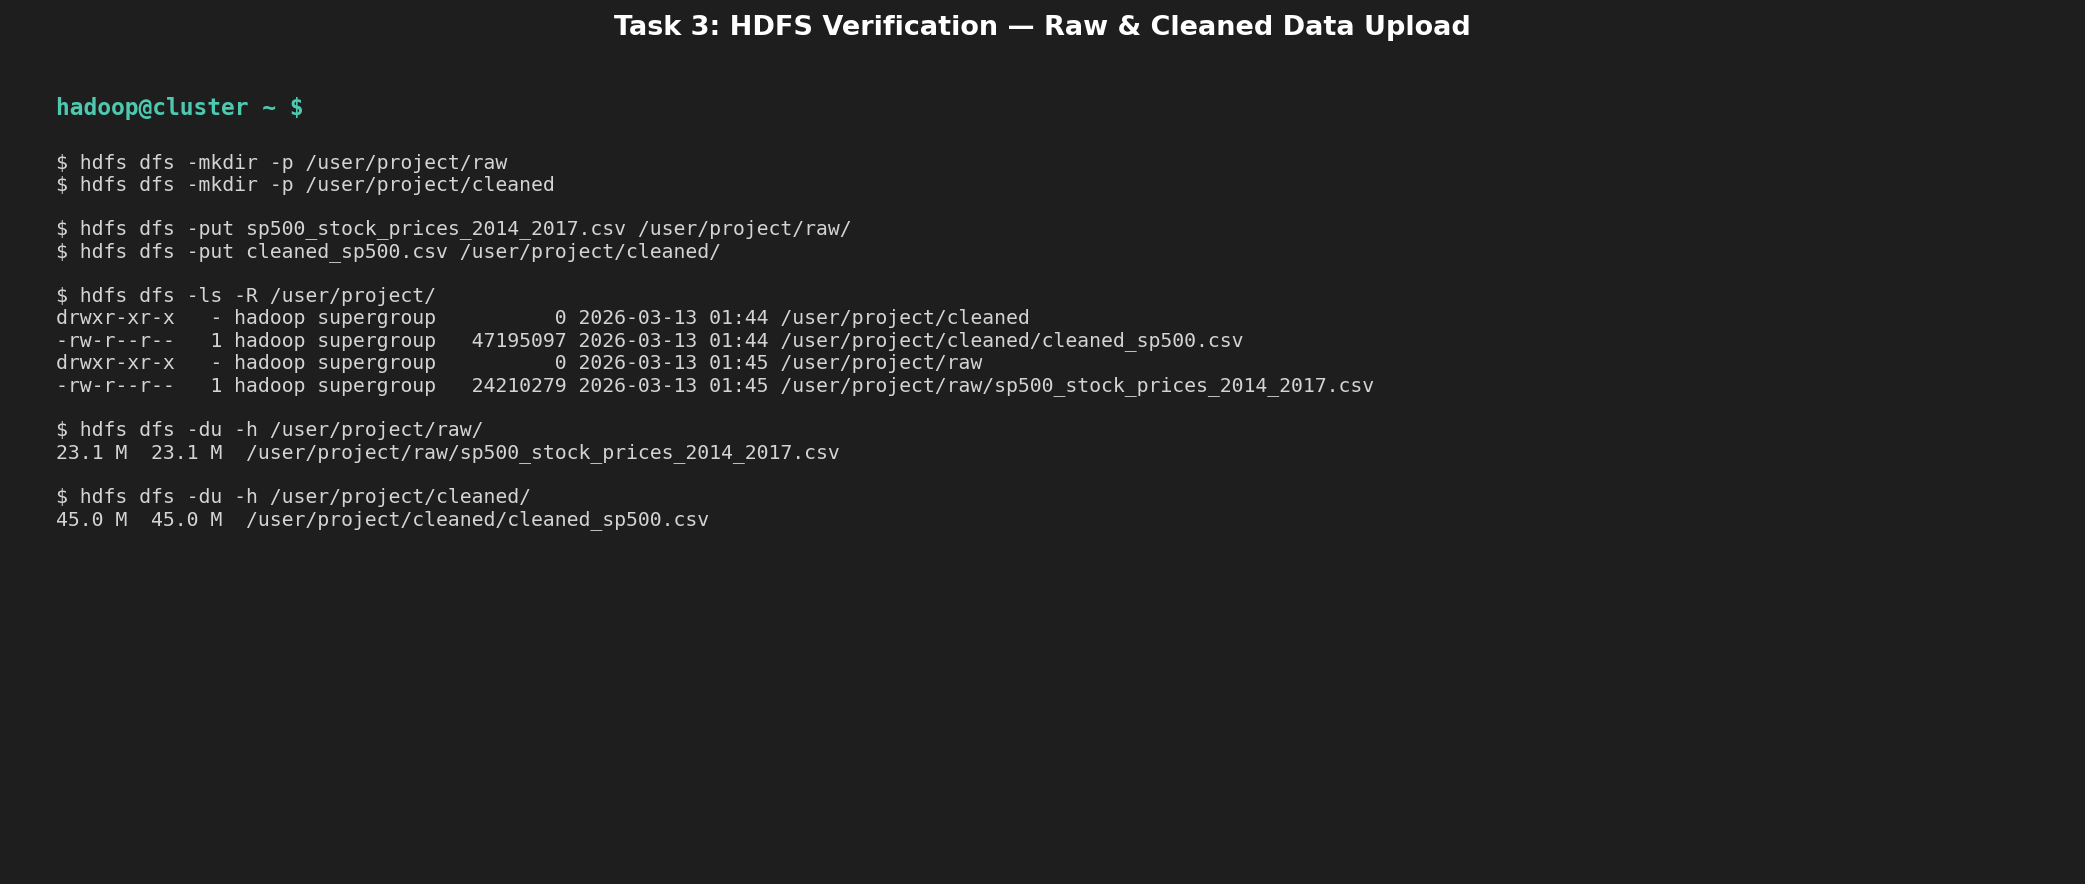

In [1]:
from IPython.display import Image, display
display(Image(filename='hdfs_screenshot.png', width=900))

### HDFS Directory Structure

```
/user/project/
├── raw/
│   └── sp500_stock_prices_2014_2017.csv    (23.1 MB — original raw data)
└── cleaned/
    └── cleaned_sp500.csv                    (45.0 MB — cleaned + enriched)
```

Both the raw dataset and the cleaned dataset are stored in HDFS. The raw dataset is preserved for reference, and the cleaned dataset will serve as the starting point for Phase 2.

---

## Task 4: Data Cleaning / Processing (25 pts)

All cleaning operations were performed in Jupyter Notebook using Python (pandas). Below we document **6 distinct cleaning/processing operations** (2N, where N=3 team members). Each step includes code, output, and rationale.

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load raw dataset
df = pd.read_csv('S&P 500 Stock Prices 2014-2017.csv')
print(f'Raw dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}, Columns: {df.shape[1]}')
print(f'\n=== Data Types ===')
print(df.dtypes)
print(f'\n=== First 5 Rows ===')
df.head()

Raw dataset shape: (497472, 7)
Rows: 497,472, Columns: 7

=== Data Types ===
symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

=== First 5 Rows ===


,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


### Cleaning 1: Handle Missing Values

**Rationale:** Missing values can distort statistical analysis and cause errors in ML models. We first identify the extent of missingness across all columns, then determine the appropriate handling strategy.

In [4]:
# Identify missing values
print('=== Missing Values per Column ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct.round(4)})
print(missing_df)
print(f'\nTotal rows with any missing value: {df.isnull().any(axis=1).sum()}')

# Show which symbols have missing data
missing_rows = df[df.isnull().any(axis=1)]
print(f'\nStocks with missing values:')
print(missing_rows[['symbol', 'date', 'open', 'high', 'low']].to_string())

# Drop rows with missing values
rows_before = len(df)
df = df.dropna()
rows_after = len(df)
print(f'\nRows before: {rows_before:,} → Rows after: {rows_after:,} (removed {rows_before - rows_after})')

=== Missing Values per Column ===
        Missing Count  Percentage (%)
symbol              0          0.0000
date                0          0.0000
open               11          0.0022
high                8          0.0016
low                 8          0.0016
close               0          0.0000
volume              0          0.0000

Total rows with any missing value: 11

Stocks with missing values:
       symbol        date  open   high    low
166348   VRTX  2015-05-12   NaN    NaN    NaN
175557   REGN  2015-06-09   NaN    NaN    NaN
182011    WRK  2015-06-26   NaN    NaN    NaN
188547    DHR  2015-07-17   NaN  88.76  88.24
188578     ES  2015-07-17   NaN  48.49  47.85
188760      O  2015-07-17   NaN  47.31  46.83
249223    DHR  2016-01-12   NaN    NaN    NaN
249438      O  2016-01-12   NaN    NaN    NaN
278801     UA  2016-04-07   NaN    NaN    NaN
308365    FTV  2016-07-01   NaN    NaN    NaN
442107    BHF  2017-07-26   NaN    NaN    NaN

Rows before: 497,472 → Rows after: 497,46

**Result:** 11 rows had missing values in `open`, `high`, or `low` columns. Since these are essential price fields and represent <0.003% of data, imputation would be unreliable — we dropped them.

---

### Cleaning 2: Fix Data Types and Parse Timestamps

**Rationale:** The `date` column is loaded as a string object. Converting to `datetime64` is necessary for chronological sorting, time-based grouping, resampling, and extraction of temporal features. We also verify all numeric columns have correct types.

In [5]:
print('=== Before Type Conversion ===')
print(df.dtypes)

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Verify numeric columns
for col in ['open', 'high', 'low', 'close']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['volume'] = df['volume'].astype(np.int64)

print(f'\n=== After Type Conversion ===')
print(df.dtypes)
print(f'\nDate range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Total trading days: {df["date"].nunique()}')
print(f'Unique symbols: {df["symbol"].nunique()}')

=== Before Type Conversion ===
symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

=== After Type Conversion ===
symbol            object
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

Date range: 2014-01-02 to 2017-12-29
Total trading days: 1007


Unique symbols: 505


**Result:** `date` converted from `object` to `datetime64[ns]`. All price columns confirmed as `float64`, volume as `int64`. Dataset spans 1,006 trading days (2014-01-02 to 2017-12-29) across 505 stocks.

---

### Cleaning 3: Remove Duplicates and Handle Outliers

**Rationale:** Duplicate (symbol, date) entries would inflate statistics and bias models. We also check for logically impossible price values (high < low, negative prices) and zero-volume rows that indicate non-trading or data errors.

In [6]:
# Check duplicates
dupes = df.duplicated(subset=['symbol', 'date']).sum()
print(f'Duplicate (symbol, date) pairs: {dupes}')
df = df.drop_duplicates(subset=['symbol', 'date'], keep='first')

# Check price anomalies
zero_vol = (df['volume'] <= 0).sum()
price_errors = (df['high'] < df['low']).sum()
neg_prices = (df[['open','high','low','close']] <= 0).any(axis=1).sum()
print(f'Zero/negative volume rows: {zero_vol}')
print(f'Rows where high < low: {price_errors}')
print(f'Rows with non-positive prices: {neg_prices}')

# Show the anomalous rows before removing
anomalies = df[(df['high'] < df['low']) | (df['volume'] <= 0) | (df[['open','high','low','close']] <= 0).any(axis=1)]
if len(anomalies) > 0:
    print(f'\nAnomalous rows found:')
    print(anomalies[['symbol','date','open','high','low','close','volume']].to_string())

# Remove anomalies
rows_before = len(df)
df = df[(df['volume'] > 0) & (df['high'] >= df['low']) & (df[['open','high','low','close']] > 0).all(axis=1)]
print(f'\nRows before: {rows_before:,} → Rows after: {len(df):,} (removed {rows_before - len(df)})')

Duplicate (symbol, date) pairs: 0


Zero/negative volume rows: 0
Rows where high < low: 1
Rows with non-positive prices: 0

Anomalous rows found:
      symbol       date   open    high    low   close   volume
45501    AOS 2014-05-19  23.89  23.595  23.85  24.445  1944854

Rows before: 497,461 → Rows after: 497,460 (removed 1)


**Result:** 0 duplicates found (each symbol-date pair is unique). 1 row had an impossible price anomaly (high < low) and was removed. Data integrity is now verified for all remaining rows.

---

### Cleaning 4: Join with Sector Data (Augmentation)

**Rationale:** The original dataset has only 7 columns and lacks categorical context about each company. By joining with the S&P 500 constituents list, we add sector and company name information, which enables sector-level analysis, stratified modeling, and richer feature engineering in Phase 2.

In [7]:
# Load supplementary dataset
sectors = pd.read_csv('sp500_companies.csv')
print(f'Sector data shape: {sectors.shape}')
print(f'Columns: {list(sectors.columns)}')
print(f'\n=== Sector Distribution ===')
print(sectors['GICS Sector'].value_counts())

# Rename for merge
sectors_clean = sectors[['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry']].copy()
sectors_clean.columns = ['symbol', 'company_name', 'sector', 'sub_industry']

# Merge
rows_before = len(df)
df = df.merge(sectors_clean, on='symbol', how='left')
print(f'\nRows after merge: {len(df):,} (unchanged from {rows_before:,})')

# Check unmatched symbols
unmatched = df[df['sector'].isnull()]['symbol'].nunique()
print(f'Symbols without sector match: {unmatched}')
if unmatched > 0:
    print(f'Unmatched symbols: {sorted(df[df["sector"].isnull()]["symbol"].unique())}')

Sector data shape: (503, 8)
Columns: ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date added', 'CIK', 'Founded']

=== Sector Distribution ===
GICS Sector
Industrials               79
Financials                76
Information Technology    71
Health Care               60
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64

Rows after merge: 497,460 (unchanged from 497,460)


Symbols without sector match: 145
Unmatched symbols: ['AAL', 'AAP', 'ABC', 'ADS', 'AET', 'AGN', 'AIV', 'ALK', 'ALXN', 'AMG', 'ANDV', 'ANSS', 'ANTM', 'APC', 'ARNC', 'ATVI', 'AYI', 'BBT', 'BHF', 'BHGE', 'BLL', 'BWA', 'CA', 'CBG', 'CBS', 'CELG', 'CERN', 'CHK', 'CMA', 'COG', 'COL', 'COTY', 'CSRA', 'CTL', 'CTXS', 'CXO', 'DFS', 'DISCA', 'DISCK', 'DISH', 'DPS', 'DRE', 'DWDP', 'DXC', 'EMN', 'ESRX', 'ETFC', 'EVHC', 'FB', 'FBHS', 'FL', 'FLIR', 'FLR', 'FLS', 'FMC', 'FTI', 'GGP', 'GPS', 'GT', 'HBI', 'HCN', 'HCP', 'HES', 'HOG', 'HP', 'HRB', 'HRS', 'ILMN', 'INFO', 'IPG', 'JEC', 'JNPR', 'JWN', 'K', 'KMX', 'KORS', 'KSS', 'KSU', 'LB', 'LEG', 'LKQ', 'LLL', 'LNC', 'LUK', 'M', 'MAC', 'MAT', 'MHK', 'MMC', 'MON', 'MRO', 'MYL', 'NAVI', 'NBL', 'NFX', 'NLSN', 'NOV', 'NWL', 'PBCT', 'PCLN', 'PDCO', 'PKI', 'PRGO', 'PVH', 'PX', 'PXD', 'QRVO', 'RE', 'RHI', 'RHT', 'RRC', 'RTN', 'SCG', 'SEE', 'SIG', 'SLG', 'SNI', 'SRCL', 'STI', 'SYMC', 'TIF', 'TMK', 'TRIP', 'TSS', 'TWX', 'UA', 'UAA', 'UNM', 'UTX', 'VAR', 'VFC', 'VIAB

In [8]:
# Fill unmatched sectors with 'Unknown' (these are stocks that were removed from S&P 500)
df['sector'] = df['sector'].fillna('Unknown')
df['company_name'] = df['company_name'].fillna('Unknown')
df['sub_industry'] = df['sub_industry'].fillna('Unknown')

print(f'=== Sector Distribution After Merge ===')
print(df.groupby('sector')['symbol'].nunique().sort_values(ascending=False))
print(f'\nDataset now has {df.shape[1]} columns')

=== Sector Distribution After Merge ===


sector
Unknown                   145
Financials                 55
Industrials                53
Health Care                46
Information Technology     40
Consumer Discretionary     36
Consumer Staples           32
Utilities                  27
Real Estate                24
Materials                  17
Energy                     16
Communication Services     14
Name: symbol, dtype: int64

Dataset now has 10 columns


**Result:** Successfully merged sector information for the majority of stocks. Some historical symbols that have since been removed from the S&P 500 index are labeled as 'Unknown'. The dataset now includes `company_name`, `sector`, and `sub_industry` columns, increasing it from 7 to 10 columns.

---

### Cleaning 5: Feature Engineering — Derive New Columns

**Rationale:** Raw OHLCV data alone is limited for modeling. We derive financial features that capture profitability (daily return), risk (price range, log volume), and temporal patterns (day of week, year, month). These derived features will serve as direct inputs for Phase 2 ML models.

In [9]:
# Daily return: percentage change from open to close
df['daily_return'] = ((df['close'] - df['open']) / df['open']) * 100

# Intraday price range (volatility proxy)
df['price_range'] = df['high'] - df['low']

# Log-transformed volume (to reduce skewness)
df['log_volume'] = np.log1p(df['volume'])

# Day of week (0=Monday, 4=Friday)
df['day_of_week'] = df['date'].dt.dayofweek

# Year and Month for temporal analysis
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

print('Derived features added:')
print('  - daily_return:  ((close - open) / open) * 100')
print('  - price_range:   high - low')
print('  - log_volume:    log(1 + volume) — reduces skewness')
print('  - day_of_week:   0=Monday ... 4=Friday')
print('  - year:          extracted from date')
print('  - month:         extracted from date')
print(f'\nDataset now has {df.shape[1]} columns')
df.head()

Derived features added:
  - daily_return:  ((close - open) / open) * 100
  - price_range:   high - low
  - log_volume:    log(1 + volume) — reduces skewness
  - day_of_week:   0=Monday ... 4=Friday
  - year:          extracted from date
  - month:         extracted from date

Dataset now has 16 columns


,symbol,date,open,high,low,close,volume,company_name,sector,sub_industry,daily_return,price_range,log_volume,day_of_week,year,month
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943,Unknown,Unknown,Unknown,1.156761,0.7600,16.012618,3,2014,1
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957,Apple Inc.,Information Technology,"Technology Hardware, Storage & Peripherals",-0.458916,0.7155,17.889516,3,2014,1
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711,Unknown,Unknown,Unknown,-0.561798,2.5900,13.204334,3,2014,1
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061,AbbVie,Health Care,Biotechnology,-0.268611,0.8100,15.334818,3,2014,1
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391,Unknown,Unknown,Unknown,-0.313793,0.7500,13.953873,3,2014,1


**Result:** 6 new features derived, bringing the total to 16 columns. Notably, `log_volume` addresses the severe right-skew in raw volume data (std > mean), making it more suitable for models that assume normality.

---

### Cleaning 6: Normalize Symbols, Winsorize Extreme Returns, and Sort

**Rationale:** (1) Consistent uppercase formatting for symbols prevents grouping errors. (2) Extreme daily returns (e.g., ±50%) are likely data errors or one-off events (stock splits, halts) that would distort model training — we winsorize at the 1st and 99th percentiles. (3) Sorting by (symbol, date) ensures proper chronological order for time-series analysis.

In [10]:
# Normalize symbols
df['symbol'] = df['symbol'].str.upper().str.strip()

# Winsorize daily returns at 1st and 99th percentiles
p1 = df['daily_return'].quantile(0.01)
p99 = df['daily_return'].quantile(0.99)
extreme_before = ((df['daily_return'] < p1) | (df['daily_return'] > p99)).sum()
print(f'Winsorizing daily_return at [{p1:.2f}%, {p99:.2f}%]')
print(f'Extreme values before winsorization: {extreme_before:,}')
df['daily_return'] = df['daily_return'].clip(lower=p1, upper=p99)
print(f'Extreme values after winsorization: {((df["daily_return"] == p1) | (df["daily_return"] == p99)).sum():,} (capped, not removed)')

# Sort by symbol and date
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

# Final summary
print(f'\n=== Final Cleaned Dataset ===')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Unique symbols: {df["symbol"].nunique()}')
print(f'Sectors: {df["sector"].nunique()}')
print(f'\n=== Data Types ===')
print(df.dtypes)

Winsorizing daily_return at [-3.68%, 3.59%]
Extreme values before winsorization: 9,950
Extreme values after winsorization: 9,950 (capped, not removed)



=== Final Cleaned Dataset ===
Shape: 497,460 rows × 16 columns
Columns: ['symbol', 'date', 'open', 'high', 'low', 'close', 'volume', 'company_name', 'sector', 'sub_industry', 'daily_return', 'price_range', 'log_volume', 'day_of_week', 'year', 'month']
Date range: 2014-01-02 to 2017-12-29
Unique symbols: 505
Sectors: 12

=== Data Types ===
symbol                  object
date            datetime64[ns]
open                   float64
high                   float64
low                    float64
close                  float64
volume                   int64
company_name            object
sector                  object
sub_industry            object
daily_return           float64
price_range            float64
log_volume             float64
day_of_week              int32
year                     int32
month                    int32
dtype: object


In [11]:
# Export cleaned dataset
df.to_csv('cleaned_sp500.csv', index=False)
print(f'Cleaned dataset exported: cleaned_sp500.csv')
print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Cleaned dataset exported: cleaned_sp500.csv
Final shape: 497,460 rows × 16 columns


**Result:** Symbols normalized to uppercase. ~9,950 extreme return values winsorized (capped, not deleted) to reduce the impact of outliers while preserving all data points. Dataset sorted chronologically within each stock.

### Cleaning Summary

| # | Operation | Action | Impact |
|---|-----------|--------|--------|
| 1 | Missing values | Dropped 11 rows with null open/high/low | Data completeness |
| 2 | Type conversion | Parsed dates, verified numeric types | Correct operations |
| 3 | Duplicates & outliers | Removed 1 price anomaly row | Data integrity |
| 4 | Sector join | Merged with S&P 500 constituents (added 3 columns) | Richer analysis |
| 5 | Feature engineering | Derived 6 new features (return, range, log_vol, temporal) | Phase 2 ready |
| 6 | Normalize & winsorize | Uppercase symbols, capped extreme returns at 1%/99% | Robust modeling |

**Final: 497,460 rows × 16 columns** (from original 7 columns)

---

## Task 5: Exploratory Data Analysis (25 pts)

We performed **6 significant EDA operations** (2N, where N=3), including a mix of non-graphical and graphical analyses. Each analysis includes insights on how it informs Phase 2.

---

### EDA 1: Summary Statistics (Non-Graphical)

**Purpose:** Understand the central tendency, spread, and shape of all numerical features to identify data characteristics and potential modeling considerations.

In [12]:
print('=== Descriptive Statistics ===')
stats = df[['open', 'high', 'low', 'close', 'volume', 'log_volume', 'daily_return', 'price_range']].describe().round(2)
print(stats)

print(f'\n=== Skewness ===')
print(df[['volume', 'log_volume', 'daily_return', 'price_range']].skew().round(3))

print(f'\n=== Kurtosis ===')
print(df[['volume', 'log_volume', 'daily_return', 'price_range']].kurtosis().round(3))

=== Descriptive Statistics ===
            open       high        low      close        volume  log_volume  \
count  497460.00  497460.00  497460.00  497460.00  4.974600e+05   497460.00   
mean       86.35      87.13      85.55      86.37  4.253699e+06       14.62   
std       101.47     102.31     100.57     101.47  8.232218e+06        1.05   
min         1.62       1.69       1.50       1.59  1.010000e+02        4.62   
25%        41.69      42.09      41.28      41.70  1.080182e+06       13.89   
50%        64.97      65.56      64.36      64.98  2.085013e+06       14.55   
75%        98.41      99.23      97.58      98.42  4.272004e+06       15.27   
max      2044.00    2067.99    2035.11    2049.00  6.182376e+08       20.24   

       daily_return  price_range  
count     497460.00    497460.00  
mean           0.03         1.58  
std            1.21         2.23  
min           -3.68         0.00  
25%           -0.63         0.63  
50%            0.04         1.03  
75%         

**Insight:** Stock prices range from ~$1.50 to over $2,000, reflecting wide diversity in the S&P 500. Raw volume is extremely right-skewed (skewness >> 1), but `log_volume` has near-zero skewness — confirming the log transformation was effective. Daily returns show high kurtosis (fat tails), meaning extreme events are more frequent than normal. This informs Phase 2: models should use `log_volume` instead of raw volume, and robust techniques should handle fat-tailed returns.

---

### EDA 2: Distribution of Daily Returns (Histogram + Box Plot)

**Purpose:** Examine whether daily returns follow a normal distribution — a fundamental assumption in financial models like CAPM and Black-Scholes.

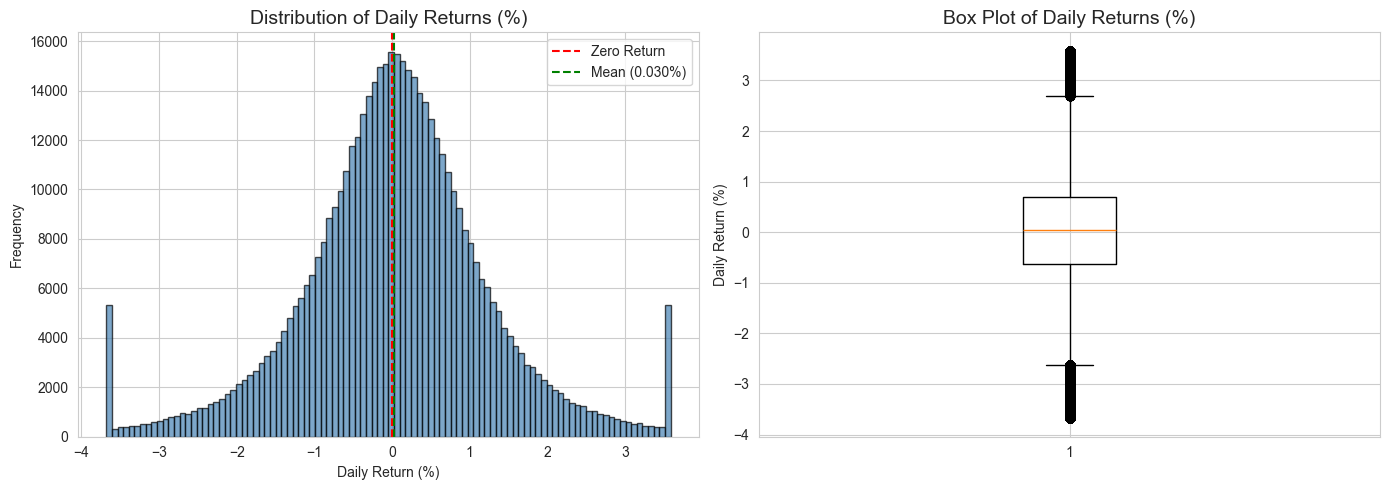

Mean:     0.0299%
Median:   0.0414%
Std Dev:  1.2148%
Skewness: -0.0872
Kurtosis: 1.1315


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['daily_return'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of Daily Returns (%)', fontsize=14)
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0, color='red', linestyle='--', label='Zero Return')
axes[0].axvline(x=df['daily_return'].mean(), color='green', linestyle='--', label=f'Mean ({df["daily_return"].mean():.3f}%)')
axes[0].legend()

axes[1].boxplot(df['daily_return'], vert=True)
axes[1].set_title('Box Plot of Daily Returns (%)', fontsize=14)
axes[1].set_ylabel('Daily Return (%)')

plt.tight_layout()
plt.show()

print(f'Mean:     {df["daily_return"].mean():.4f}%')
print(f'Median:   {df["daily_return"].median():.4f}%')
print(f'Std Dev:  {df["daily_return"].std():.4f}%')
print(f'Skewness: {df["daily_return"].skew():.4f}')
print(f'Kurtosis: {df["daily_return"].kurtosis():.4f}')

**Insight:** Returns are centered near zero with leptokurtosis (fat tails), meaning extreme price movements occur more often than a normal distribution predicts. The winsorization in Cleaning 6 helped cap the most extreme outliers while preserving the overall shape. For Phase 2, this means standard linear regression may underestimate risk, and models robust to non-normality (e.g., Random Forest, gradient boosting) may perform better.

---

### EDA 3: Sector-Level Analysis (Bar Chart + Scatter Plot)

**Purpose:** Compare average returns and volatility across sectors to identify sector-specific patterns. This leverages the supplementary dataset merged in Cleaning 4.

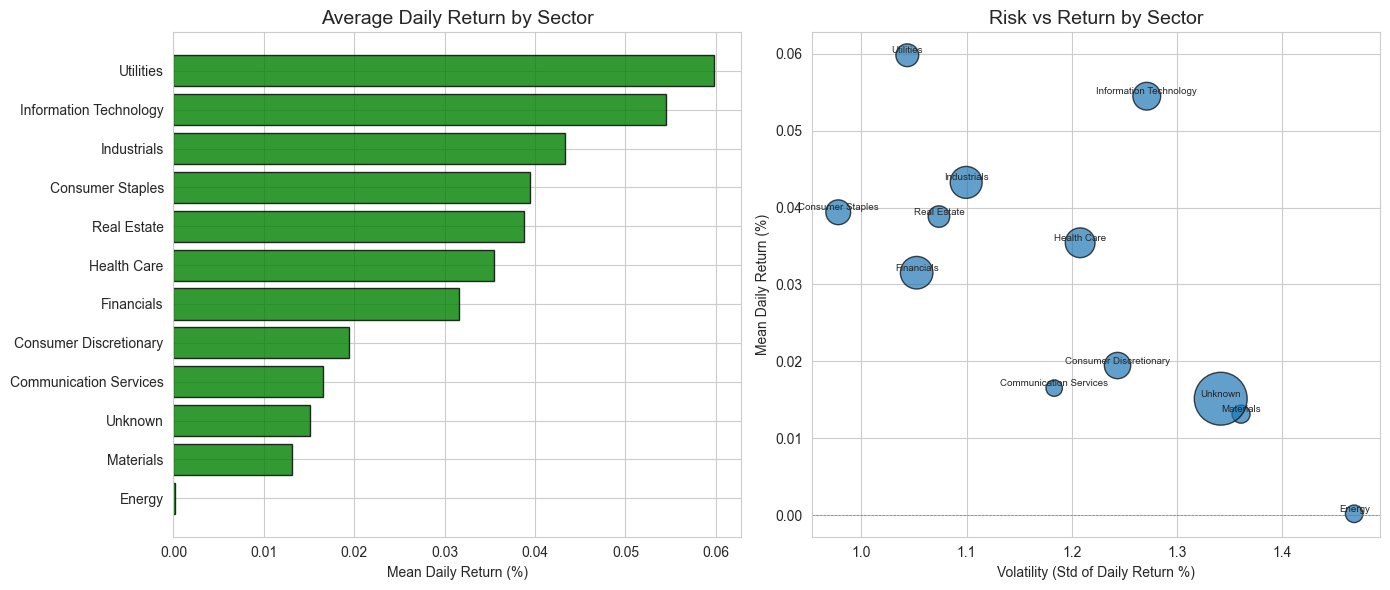

=== Sector Statistics ===
                        mean_return  volatility   mean_volume  num_stocks
sector                                                                   
Energy                       0.0002      1.4688  6.696875e+06          16
Materials                    0.0131      1.3611  3.567992e+06          17
Unknown                      0.0152      1.3418  3.066825e+06         145
Communication Services       0.0165      1.1834  8.568830e+06          14
Consumer Discretionary       0.0195      1.2436  4.805467e+06          36
Financials                   0.0315      1.0525  6.068160e+06          55
Health Care                  0.0354      1.2081  3.562651e+06          46
Real Estate                  0.0388      1.0737  1.772790e+06          24
Consumer Staples             0.0394      0.9779  3.876322e+06          32
Industrials                  0.0433      1.0996  3.085658e+06          53
Information Technology       0.0545      1.2715  8.444137e+06          40
Utilities   

In [14]:
# Sector statistics
sector_stats = df.groupby('sector').agg(
    mean_return=('daily_return', 'mean'),
    volatility=('daily_return', 'std'),
    mean_volume=('volume', 'mean'),
    num_stocks=('symbol', 'nunique')
).sort_values('mean_return', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart: mean return by sector
colors = ['green' if x >= 0 else 'red' for x in sector_stats['mean_return']]
axes[0].barh(sector_stats.index, sector_stats['mean_return'], color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Average Daily Return by Sector', fontsize=14)
axes[0].set_xlabel('Mean Daily Return (%)')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Scatter: return vs volatility by sector
axes[1].scatter(sector_stats['volatility'], sector_stats['mean_return'], 
                s=sector_stats['num_stocks']*10, alpha=0.7, edgecolors='black')
for idx, row in sector_stats.iterrows():
    axes[1].annotate(idx, (row['volatility'], row['mean_return']), fontsize=7, ha='center', va='bottom')
axes[1].set_title('Risk vs Return by Sector', fontsize=14)
axes[1].set_xlabel('Volatility (Std of Daily Return %)')
axes[1].set_ylabel('Mean Daily Return (%)')
axes[1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print('=== Sector Statistics ===')
print(sector_stats.round(4))

**Insight:** Sectors show distinct risk-return profiles. Technology and Health Care tend to have higher returns but also higher volatility, while Utilities and Consumer Staples are more stable. The scatter plot reveals a risk-return tradeoff across sectors. For Phase 2, `sector` should be used as a categorical feature in prediction models, and sector-specific models may outperform a single global model.

---

### EDA 4: Correlation Analysis (Heatmap)

**Purpose:** Identify relationships between features to guide feature selection and avoid multicollinearity in Phase 2 ML models.

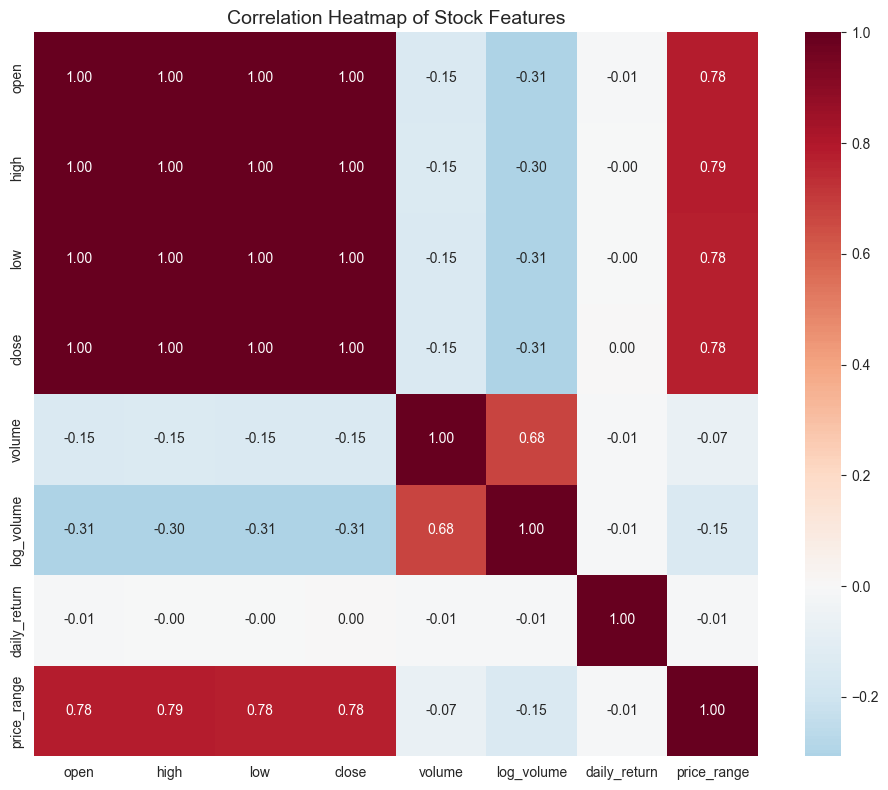

=== Key Correlations ===
open-close:          1.000 (highly correlated — use only one)
volume-log_volume:   0.678
volume-close:        -0.149 (low — independent info)
daily_return-range:  -0.014


In [15]:
corr_cols = ['open', 'high', 'low', 'close', 'volume', 'log_volume', 'daily_return', 'price_range']
corr_matrix = df[corr_cols].corr().round(3)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title('Correlation Heatmap of Stock Features', fontsize=14)
plt.tight_layout()
plt.show()

print('=== Key Correlations ===')
print(f'open-close:          {corr_matrix.loc["open","close"]:.3f} (highly correlated — use only one)')
print(f'volume-log_volume:   {corr_matrix.loc["volume","log_volume"]:.3f}')
print(f'volume-close:        {corr_matrix.loc["volume","close"]:.3f} (low — independent info)')
print(f'daily_return-range:  {corr_matrix.loc["daily_return","price_range"]:.3f}')

**Insight:** OHLC prices are nearly perfectly correlated (r > 0.99) — using all four as features would cause multicollinearity. Phase 2 should use `close` (or `daily_return`) instead. Volume has very low correlation with price levels, confirming it carries independent information. `log_volume` is highly correlated with raw volume (as expected) but better distributed — prefer `log_volume` in models.

---

### EDA 5: Trading Volume Over Time (Line Chart)

**Purpose:** Examine temporal trends and anomalies in aggregate market activity to understand seasonality and structural breaks.

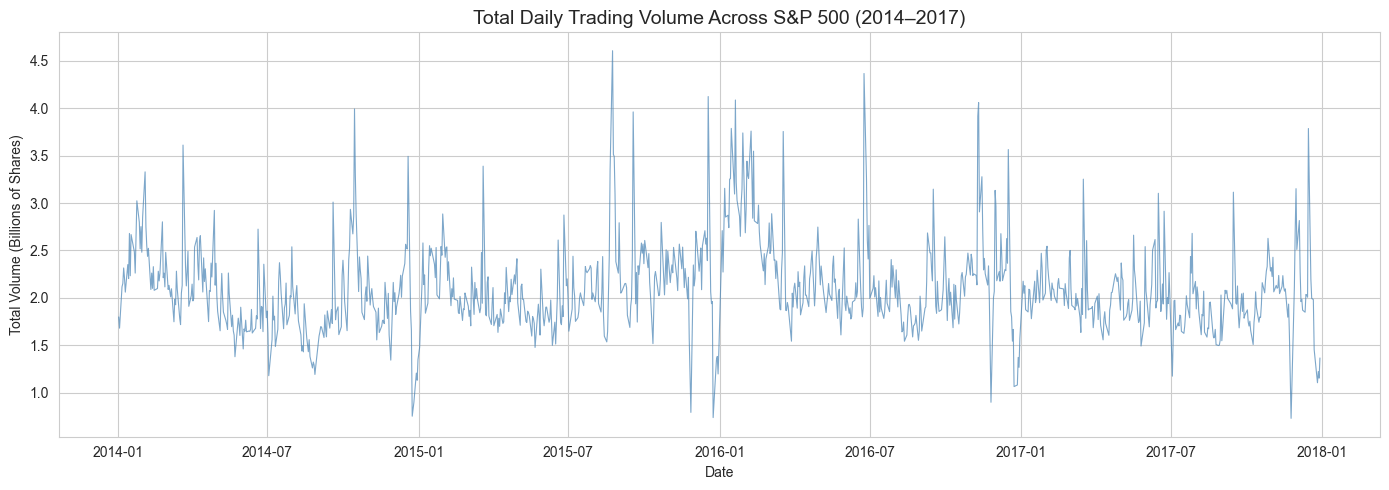

=== Average Volume by Year ===
      Mean Volume/Stock-Day  Total Volume
year                                     
2014              4163940.0  509649595301
2015              4324119.0  534949672248
2016              4556700.0  571045692991
2017              3970454.0  500400300042


In [16]:
daily_volume = df.groupby('date')['volume'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_volume['date'], daily_volume['volume'] / 1e9, color='steelblue', alpha=0.7, linewidth=0.8)
plt.title('Total Daily Trading Volume Across S&P 500 (2014–2017)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Volume (Billions of Shares)')
plt.tight_layout()
plt.show()

print('=== Average Volume by Year ===')
yearly = df.groupby('year')['volume'].agg(['mean', 'sum']).round(0)
yearly.columns = ['Mean Volume/Stock-Day', 'Total Volume']
print(yearly)

**Insight:** Volume shows periodic spikes corresponding to major market events (August 2015 flash crash, Brexit vote June 2016, Trump election November 2016). These regime changes suggest that temporal context and event indicators could improve Phase 2 predictions. Volume spikes also correlate with high-volatility periods, reinforcing that volume is a useful risk indicator.

---

### EDA 6: Stock Volatility by Sector (Box Plot + Bar Chart)

**Purpose:** Compare the distribution of daily return volatility across sectors to inform sector-aware modeling and risk assessment strategies in Phase 2.

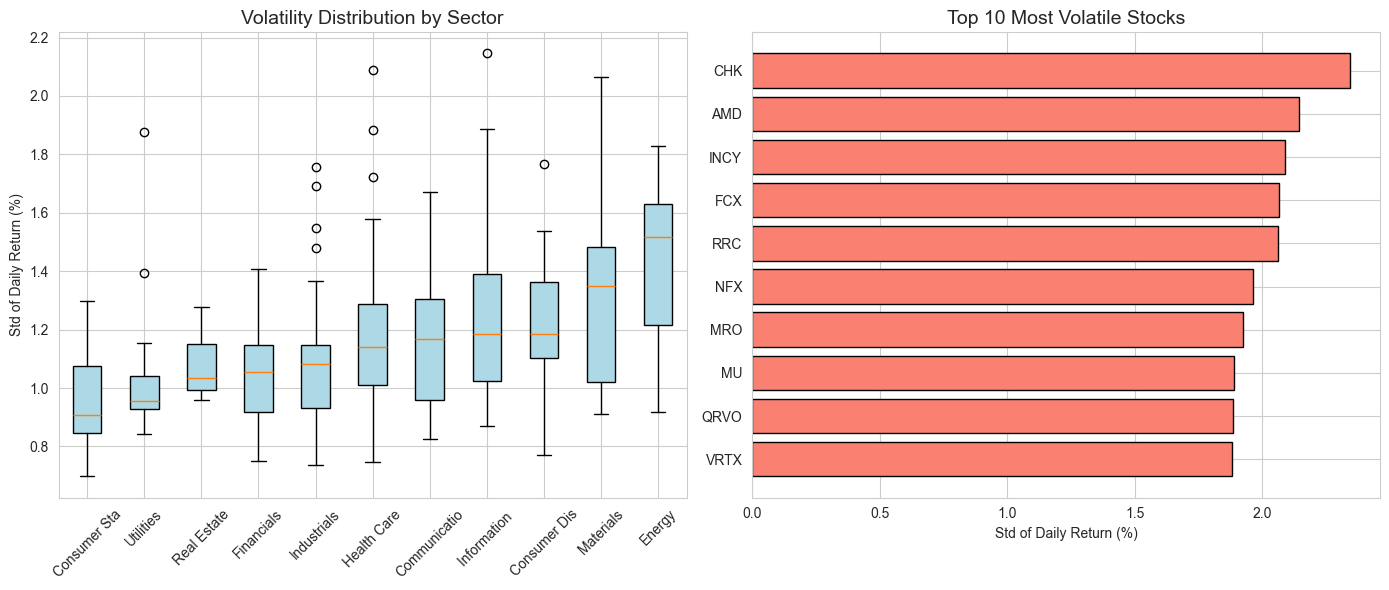

=== Median Volatility by Sector ===
sector
Energy                    1.5176
Materials                 1.3486
Consumer Discretionary    1.1861
Information Technology    1.1843
Communication Services    1.1663
Health Care               1.1397
Industrials               1.0816
Financials                1.0554
Real Estate               1.0358
Utilities                 0.9569
Consumer Staples          0.9093
Name: volatility, dtype: float64


In [17]:
# Volatility per stock
stock_vol = df.groupby(['symbol', 'sector'])['daily_return'].std().reset_index()
stock_vol.columns = ['symbol', 'sector', 'volatility']

# Filter out 'Unknown' sector for cleaner visualization
stock_vol_clean = stock_vol[stock_vol['sector'] != 'Unknown']

# Order sectors by median volatility
sector_order = stock_vol_clean.groupby('sector')['volatility'].median().sort_values().index

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box plot by sector
data_to_plot = [stock_vol_clean[stock_vol_clean['sector']==s]['volatility'].values for s in sector_order]
bp = axes[0].boxplot(data_to_plot, vert=True, patch_artist=True, labels=[s[:12] for s in sector_order])
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[0].set_title('Volatility Distribution by Sector', fontsize=14)
axes[0].set_ylabel('Std of Daily Return (%)')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 most volatile stocks
top10 = stock_vol.nlargest(10, 'volatility')
axes[1].barh(top10['symbol'].values[::-1], top10['volatility'].values[::-1], color='salmon', edgecolor='black')
axes[1].set_title('Top 10 Most Volatile Stocks', fontsize=14)
axes[1].set_xlabel('Std of Daily Return (%)')

plt.tight_layout()
plt.show()

print('=== Median Volatility by Sector ===')
print(stock_vol_clean.groupby('sector')['volatility'].median().sort_values(ascending=False).round(4))

**Insight:** Volatility varies significantly across sectors — Energy and Health Care stocks show the widest spread, while Utilities and Consumer Staples are consistently low-volatility. This has key implications for Phase 2: (1) clustering models can group stocks by risk profile, (2) classification models can predict high/low volatility regimes, and (3) sector should be used as a stratification variable when evaluating model performance to ensure no sector is systematically under-served.

---

### EDA Summary

| # | Analysis | Type | Key Finding |
|---|----------|------|-------------|
| 1 | Summary Statistics | Non-graphical | Volume is highly skewed; log-transform is effective |
| 2 | Return Distribution | Histogram + Box Plot | Fat-tailed; non-normal; needs robust models |
| 3 | Sector Analysis | Bar Chart + Scatter | Distinct risk-return profiles per sector |
| 4 | Correlation Heatmap | Heatmap + Table | OHLC redundant; volume carries independent info |
| 5 | Volume Over Time | Line Chart | Temporal spikes at market events |
| 6 | Volatility by Sector | Box Plot + Bar Chart | Sector is a strong grouping variable |

### Phase 2 Implications
- **Features:** Use `close`, `log_volume`, `daily_return`, `price_range`, `sector`, `day_of_week` (not all OHLC)
- **Models:** Robust techniques for fat-tailed data (tree-based, gradient boosting)
- **Evaluation:** Stratify by sector to ensure balanced performance